In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import glob, re, os
import ternary
import matplotlib.colors as mcolors
from scipy.stats import ttest_ind

In [3]:
experiment = 'Pro_Iso_Iso_diff'
SaveDirectory = fr'C:\Users\Redaelli\Desktop\PostDoc\ImageAnalysis\Pipeline_v4\JupyterPlots\Pro_Iso_Iso_diff'
Magnification = 150
ConversionFactor = 6.5/Magnification
#os.makedirs(f'{output_directory}', exist_ok=True)
COLOR_RED = '#DC143C'
COLOR_BLUE = '#4682B4'
code_name_species_mapping = {0: 'PRO', 1: 'ISO'}
species_colors = {'PRO': COLOR_RED, 'ISO': COLOR_BLUE}
code_colors = {0.0: COLOR_RED, 1.0: COLOR_BLUE}
# Low concentration in lower numbered series
# High concentration in higher numbered series
# Top chamber : PRO
# Low chamber: ISO

Series_list = [1, 2, 8, 11, 21, 51, 53, 55, 81, 511, 531, 551]
red_list = [1, 2, 8, 51, 53, 55]
color_scheme = {'red': red_list, 'blue': list(set(Series_list) - set(red_list))}
alpha_scheme = {0.5: [1, 2, 8, 11, 21, 81], 1.0: [51, 53, 55, 511, 531, 551]} # Mimic the High-Low level of provided Iso
label_map = {'red': 'PRO', 'blue': 'ISO'}
FIGSIZE = (6,6)

# Growth data

In [100]:
def PlotDictColors(all_elon, color_scheme, alpha_scheme=None, significance_pairs=None, label_map=None, SaveDirectory=None):
    """
    all_elon: dict, keys like '1','2','3' etc. (Series numbers), values = pd.Series
    color_scheme: dict, e.g. {'red': [1,2,3], 'blue': [4,5]}
    alpha_scheme: dict, e.g. {0.3: [1,2], 0.7: [3,4]}  # optional, transparency
    significance_pairs: list of tuples, e.g. [(1,3), (2,4)]
    label_map: dict mapping color -> label, e.g. {'red': 'PRO', 'blue': 'ISO'}
    """
    colors = []
    alphas = []
    labels = []

    for key in all_elon.keys():
        num = int(key)

        # Assign color
        assigned_color = "gray"
        assigned_label = key
        for color, nums in color_scheme.items():
            if num in nums:
                assigned_color = color
                if label_map and color in label_map:
                    assigned_label = label_map[color]
                break
        colors.append(assigned_color)
        labels.append(assigned_label)

        # Assign alpha
        assigned_alpha = 1.0
        if alpha_scheme:
            for alpha_val, nums in alpha_scheme.items():
                if num in nums:
                    assigned_alpha = alpha_val
                    break
        alphas.append(assigned_alpha)

    # Convert dictionary to DataFrame
    
    # --- Bar Plot (mean ± std) ---
    means = {k: v.mean() for k, v in all_elon.items()}
    stds = {k: v.std() /np.sqrt(len(v)) for k, v in all_elon.items()}
    
    # Create dataframe with per chamber values
    df_chamber = pd.DataFrame({
        'key': list(means.keys()),
        'mean': list(means.values()),
        'std': list(stds.values())
    })
    
    # Map alpha
    df_chamber['alpha'] = df_chamber['key'].apply(lambda k: 0.5 if k in alpha_scheme[0.5] else 1.0)
    
    # Map color
    df_chamber['color'] = df_chamber['key'].apply(lambda k: 'red' if k in color_scheme['red'] else 'blue')

    # --- Violin Plot ---
    #df_plot = pd.DataFrame(all_elon)
    #plt.figure(figsize=FIGSIZE)
    #for i, col in enumerate(df_plot.columns):
    #    sns.violinplot(data=df_plot[[col]], color=colors[i], alpha=alphas[i])
    #plt.xticks(range(len(df_plot.columns)), labels, rotation=45, ha="right")
    #plt.ylabel(r" Elongation rate [$\mu m/s$]")
    #plt.tight_layout()
    #if SaveDirectory:
    #    plt.savefig(f'{SaveDirectory}/ViolinGrowIsoConc.png')
    #plt.show()

    
    
    #plt.figure(figsize=FIGSIZE)
    #for i, (k, v) in enumerate(means.items()):
    #    plt.bar(i, v, yerr=stds[k], color=colors[i], alpha=alphas[i], capsize=5)
    #plt.xticks(range(len(means)), labels, rotation=45, ha="right")
    #plt.ylabel(r" Elongation rate [$\mu m/s$]")
    #plt.tight_layout()
    if SaveDirectory:
        plt.savefig(f'{SaveDirectory}/BarplotGrowIsoConc.png')

    return df_chamber

In [101]:
dict_growth ={}
for series in Series_list:
    df = pd.read_csv(fr'C:\Users\Redaelli\Desktop\PostDoc\ImageAnalysis\WithMidap\{experiment}\Series_{series}\raw_images_half\AnalysisNoMixing\Growth_df.csv')
    df = df[(df['Elongation_rate']) < 1.9 * (df['Elongation_rate'] > 0.0 )].copy()
    df = df[df['Timepoint']*1/6 > 10].copy() # after 10 hours, excluding initial feeding through residual aminoacids
    dict_growth[series] = df['Elongation_rate']

# Don not eliminate those that do not grow since it's those that shift the average down for the 

In [102]:
df_chamber = PlotDictColors(dict_growth, color_scheme, alpha_scheme, significance_pairs=[(1, 55), (11, 551)], label_map =label_map, SaveDirectory=SaveDirectory)

<Figure size 640x480 with 0 Axes>

# Elongation rates

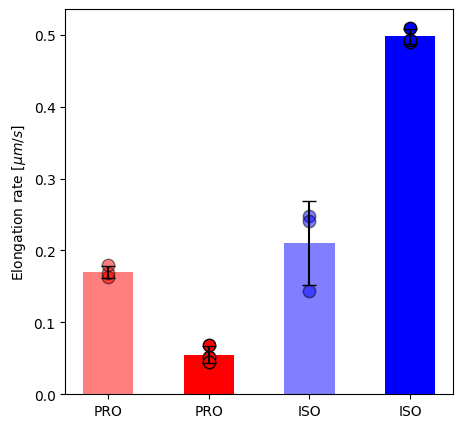

In [103]:
# Define unique x positions for color/alpha combinations
combos = [(c, a) for c in ['red','blue'] for a in [0.5, 1.0]]
x_pos = {combo: i for i, combo in enumerate(combos)}

fig, ax = plt.subplots(figsize=(5,5))

# Plot bars with mean of means and std of means
for combo, i in x_pos.items():
    sub = df_chamber[(df_chamber['color'] == combo[0]) & (df_chamber['alpha'] == combo[1])]
    mean_of_means = sub['mean'].mean()
    std_of_means = sub['mean'].std()
    ax.bar(i, mean_of_means, yerr=std_of_means, color=combo[0], alpha=combo[1], capsize=5, width=0.5)
    
# Plot scatter points
for _, row in df_chamber.iterrows():
    x = x_pos[(row['color'], row['alpha'])]
    ax.scatter(x, row['mean'], color=row['color'], alpha=row['alpha'], s=80, edgecolor='k')



# Customize
ax.set_xticks(range(4))
ax.set_xticklabels(['PRO', 'PRO', 'ISO', 'ISO'])
#ax.set_xticklabels([f"{c}/{a}" for c,a in combos])
ax.set_ylabel(r"Elongation rate [$\mu m / s$]")
#ax.set_title("Means by Color/Alpha")
plt.savefig(f'{SaveDirectory}/BarplotGrowIsoConc_v2_Exp1.png')
plt.show()

# Check growth - position

## Exchange condition

In [4]:
Distance_chosen = 5 #micron

In [8]:
dict_growth_exchange ={}

Exchange_chambers = [1, 2, 8, 11, 21, 81]
for series in Exchange_chambers:
    df = pd.read_csv(fr'C:\Users\Redaelli\Desktop\PostDoc\ImageAnalysis\WithMidap\{experiment}\Series_{series}\raw_images_half\AnalysisNoMixing\Growth_df.csv')
    df = df[(df['Elongation_rate']) < 1.9 * (df['Elongation_rate'] > 0.0 )].copy()
    df = df[df['Timepoint']*1/6 > 10].copy() # after 10 hours, excluding initial feeding through residual aminoacids
    dict_growth_exchange[series] = df


In [11]:
# Combine and filter all DataFrames
filtered_list_exchange = []

for series, df in dict_growth_exchange.items():
    df_filtered = df[df['Elongation_rate'] > 0]
    df_clean_excess_length = df_filtered[df_filtered.axis_major_length*ConversionFactor < 2.5]
    df_growth = df_clean_excess_length[df_clean_excess_length['Elongation_rate'] < 2.0].copy()
    df_growth['Series'] = series
    if series in red_list:
        df_growth['Species'] = 0.0
        df_growth['Species_name'] = 'PRO'
    else:
        df_growth['Species'] = 1.0
        df_growth['Species_name'] = 'ISO'
        
    filtered_list_exchange.append(df_growth)

df_growth_pos_exchange = pd.concat(filtered_list_exchange, ignore_index=True)


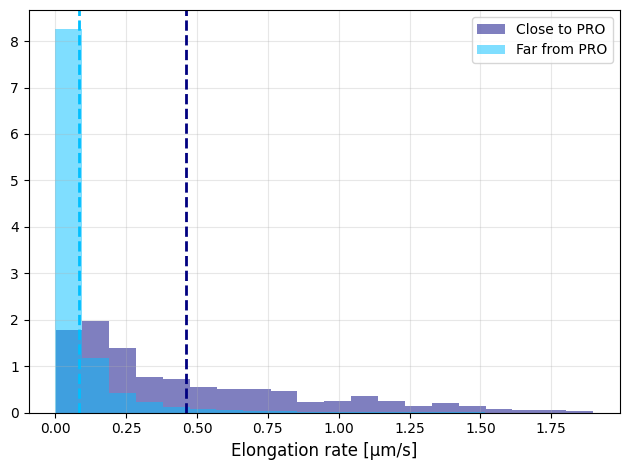

In [16]:
CellsCloseToPartner = df_growth_pos_exchange[(df_growth_pos_exchange['Species'] == 1.0) * (df_growth_pos_exchange['centroid-0'] <= Distance_chosen *1/ConversionFactor)]['Elongation_rate']
CellsFarFromPartner = df_growth_pos_exchange[(df_growth_pos_exchange['Species'] == 1.0) * (df_growth_pos_exchange['centroid-0'] > Distance_chosen *1/ConversionFactor)]['Elongation_rate']

# Histograms
plt.hist(
    CellsCloseToPartner, 
    density=True, bins=20, 
    alpha=0.5, color='navy', 
    label='Close to PRO'
)

plt.hist(
    CellsFarFromPartner,
    density=True, bins=20,
    alpha=0.5, color='deepskyblue',
    label='Far from PRO'
)

# Mean lines
plt.axvline(np.mean(CellsCloseToPartner), color='navy', linestyle='--', linewidth=2)
plt.axvline(np.mean(CellsFarFromPartner), color='deepskyblue', linestyle='--', linewidth=2)

# Labels and title
plt.xlabel('Elongation rate [µm/s]', fontsize=12)

# Grid and legend
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig(f'{SaveDirectory}/FarCloseComparison_noISO.png')
plt.show()

## High Iso condition 

In [13]:
dict_growth_high ={}

High_chambers =[51, 53, 55, 511, 531, 551]
for series in High_chambers:
    df = pd.read_csv(fr'C:\Users\Redaelli\Desktop\PostDoc\ImageAnalysis\WithMidap\{experiment}\Series_{series}\raw_images_half\AnalysisNoMixing\Growth_df.csv')
    df = df[(df['Elongation_rate']) < 1.9 * (df['Elongation_rate'] > 0.0 )].copy()
    df = df[df['Timepoint']*1/6 > 10].copy() # after 10 hours, excluding initial feeding through residual aminoacids
    dict_growth_high[series] = df


In [14]:
# Combine and filter all DataFrames
filtered_list_high = []

for series, df in dict_growth_high.items():
    df_filtered = df[df['Elongation_rate'] > 0]
    df_clean_excess_length = df_filtered[df_filtered.axis_major_length*ConversionFactor < 2.5]
    df_growth = df_clean_excess_length[df_clean_excess_length['Elongation_rate'] < 2.0].copy()
    df_growth['Series'] = series
    if series in red_list:
        df_growth['Species'] = 0.0
        df_growth['Species_name'] = 'PRO'
    else:
        df_growth['Species'] = 1.0
        df_growth['Species_name'] = 'ISO'
        
    filtered_list_high.append(df_growth)

df_growth_high = pd.concat(filtered_list_high, ignore_index=True)


5775     0.469290
5776     0.679394
5784     0.423830
5788     0.316098
5794     1.421137
           ...   
24032    0.544975
24035    0.312399
24046    0.380354
24048    0.658731
24053    0.347367
Name: Elongation_rate, Length: 4900, dtype: float64


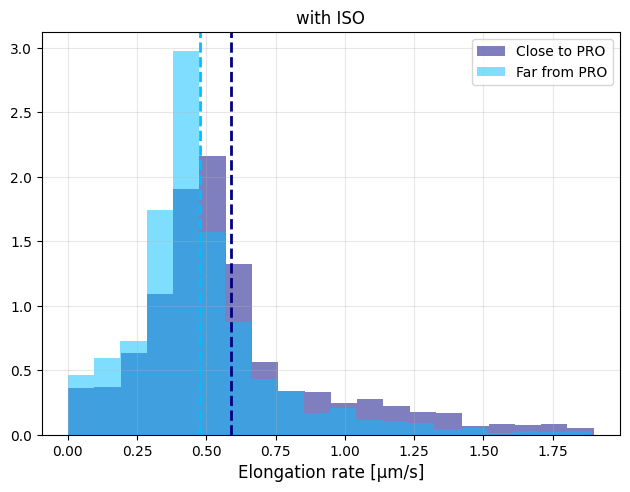

In [15]:
CellsCloseToPartner = df_growth_high[(df_growth_high['Species'] == 1.0) * (df_growth_high['centroid-0'] <= Distance_chosen *1/ConversionFactor)]['Elongation_rate']
CellsFarFromPartner = df_growth_high[(df_growth_high['Species'] == 1.0) * (df_growth_high['centroid-0'] > Distance_chosen *1/ConversionFactor)]['Elongation_rate']
print(CellsCloseToPartner)

# Histograms
plt.hist(
    CellsCloseToPartner, 
    density=True, bins=20, 
    alpha=0.5, color='navy', 
    label='Close to PRO'
)

plt.hist(
    CellsFarFromPartner,
    density=True, bins=20,
    alpha=0.5, color='deepskyblue',
    label='Far from PRO'
)

# Mean lines
plt.axvline(np.mean(CellsCloseToPartner), color='navy', linestyle='--', linewidth=2)
plt.axvline(np.mean(CellsFarFromPartner), color='deepskyblue', linestyle='--', linewidth=2)

# Labels and title
plt.xlabel('Elongation rate [µm/s]', fontsize=12)

# Grid and legend
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.title('with ISO')
plt.savefig(f'{SaveDirectory}/FarCloseComparison_withISO.png')
plt.show()